<a href="https://colab.research.google.com/github/Phalguni-dhabale/MV-LAB/blob/main/MV_P9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!apt-get update
!apt-get install -y tesseract-ocr
!pip install opencv-python pytesseract

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [4,685 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [3,186 kB]
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,316 kB]
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.8 MB]
Get:14 http://archi

In [2]:
import cv2
import pytesseract
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Configure pytesseract path (if necessary, though Colab often finds it automatically)
# pytesseract.pytesseract.tesseract_cmd = r'/usr/bin/tesseract' # This is often the default path on Colab

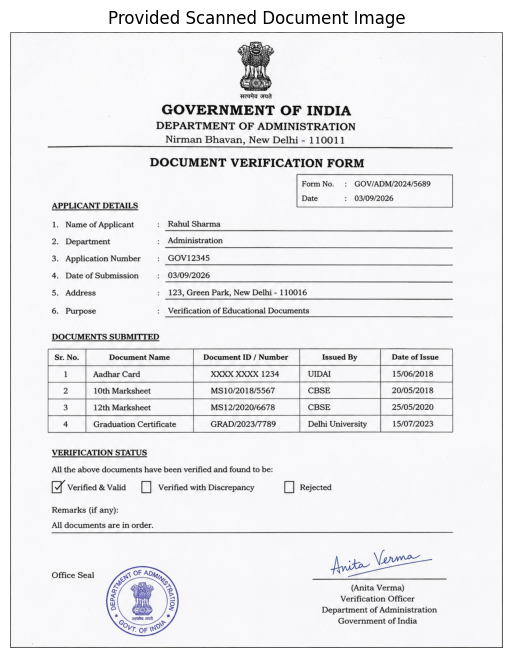

In [3]:
import cv2
import os
import matplotlib.pyplot as plt

# Use the provided document image
image_filename = "/content/document.png"

# Load the image using OpenCV
image = cv2.imread(image_filename)

# Check if the image was loaded successfully
if image is None:
    print(f"Error: Could not load image from {image_filename}")
else:
    # Convert to RGB for matplotlib display
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Display the original image
    plt.figure(figsize=(10, 8))
    plt.imshow(image_rgb)
    plt.title('Provided Scanned Document Image')
    plt.axis('off')
    plt.show()

## 2. Image Preprocessing

Image preprocessing is a critical step to improve the quality of the scanned document before performing OCR. This helps to enhance the contrast, remove noise, and standardize the image, leading to better text extraction accuracy. We will apply grayscaling, noise reduction, and binarization.

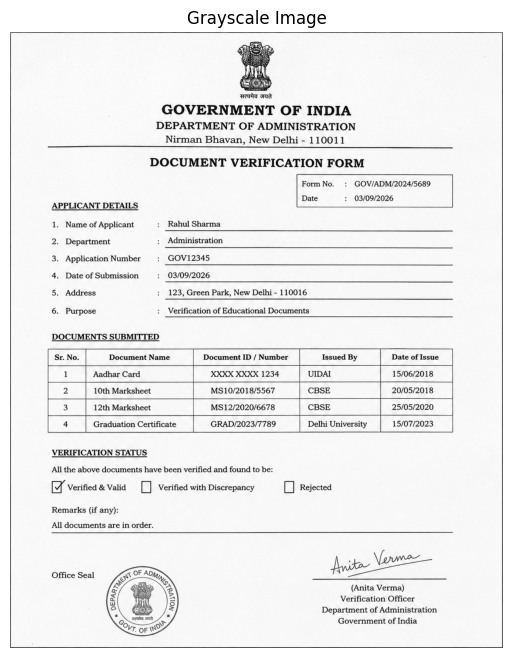

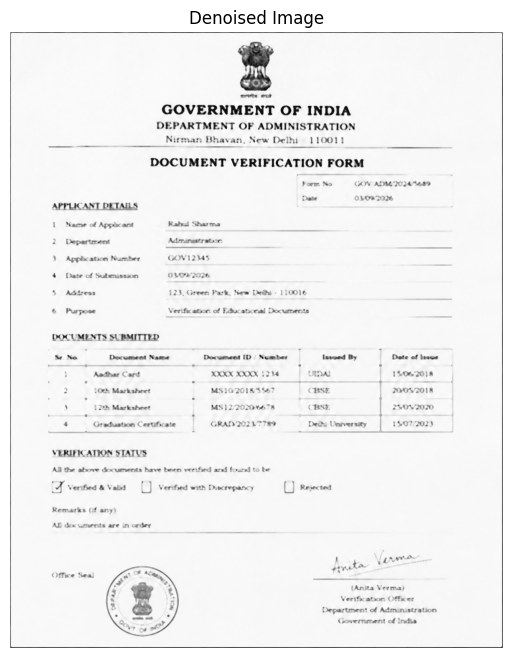

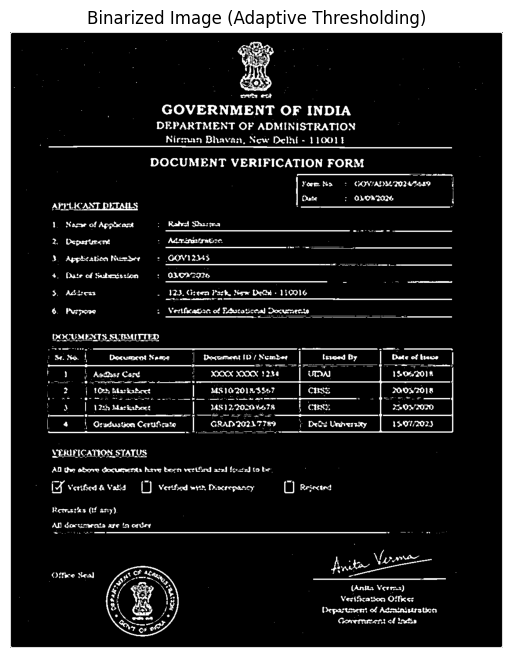

Image preprocessing steps completed: Grayscaling, Denoising, and Binarization.


In [6]:
# 1. Convert to Grayscale
grayscale_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Display Grayscale Image
plt.figure(figsize=(10, 8))
plt.imshow(grayscale_image, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')
plt.show()

# 2. Noise Reduction (using a median blur filter)
denoised_image = cv2.medianBlur(grayscale_image, 5) # Kernel size 5 is common

# Display Denoised Image
plt.figure(figsize=(10, 8))
plt.imshow(denoised_image, cmap='gray')
plt.title('Denoised Image')
plt.axis('off')
plt.show()

# 3. Binarization (using adaptive thresholding)
# ADAPTIVE_THRESH_GAUSSIAN_C is good for images with varying illumination
# THRESH_BINARY_INV means text will be black and background white (often preferred by Tesseract)
binary_image = cv2.adaptiveThreshold(
    denoised_image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV, 11, 2
)

# Display Binary Image
plt.figure(figsize=(10, 8))
plt.imshow(binary_image, cmap='gray')
plt.title('Binarized Image (Adaptive Thresholding)')
plt.axis('off')
plt.show()

print("Image preprocessing steps completed: Grayscaling, Denoising, and Binarization.")

## 3. Optical Character Recognition (OCR)

With the preprocessed image, we can now use Tesseract to extract the text. The quality of the preprocessing directly impacts the accuracy of the OCR.

In [4]:
# Perform OCR on the binarized image
extracted_text = pytesseract.image_to_string(binary_image)

print("--- Extracted Text ---")
print(extracted_text)
print("----------------------")

NameError: name 'binary_image' is not defined

In [5]:
import re

# Define regex patterns for specific fields
form_no_pattern = r"Form No\.\s*:\s*(GOV/ADM/\d{4}/\d{4})"
application_number_pattern = r"Application Number\s*(?:[\s:]*)\s*([A-Za-z0-9]+)"

# Search for the patterns in the extracted text
form_no_match = re.search(form_no_pattern, extracted_text)
application_number_match = re.search(application_number_pattern, extracted_text)

print("--- Text Validation Results ---")

# Extract and print Form No.
if form_no_match:
    form_no = form_no_match.group(1)
    print(f"Extracted Form No.: {form_no}")
    # Further validation could be added here, e.g., check if year is current, etc.
else:
    print("Form No. not found.")

# Extract and print Application Number
if application_number_match:
    application_number = application_number_match.group(1)
    print(f"Extracted Application Number: {application_number}")
else:
    print("Application Number not found.")

# Example of general keyword validation
if "Verified & Valid" in extracted_text:
    print("Status: 'Verified & Valid' found in document.")
else:
    print("Status: 'Verified & Valid' not explicitly found.")

print("-------------------------------")

NameError: name 'extracted_text' is not defined